# S6E2 Baseline Model Testing
Kaggle Playground Series S6E2 — Heart Disease Prediction

This notebook builds on the EDA findings to test progressively complex models:
1. Manual threshold rules (intuition-driven)
2. Shallow decision tree (automated rule discovery)

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

## Data Loading

In [2]:
KAGGLE_DATA = Path("/kaggle/input/playground-series-s6e2")
LOCAL_DATA  = Path("data")
DATA_DIR    = KAGGLE_DATA if KAGGLE_DATA.exists() else LOCAL_DATA

train = pd.read_csv(DATA_DIR / "train.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")
ss    = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"Train: {train.shape}  Test: {test.shape}")

Train: (630000, 15)  Test: (270000, 14)


## Preprocessing

In [3]:
def clean_column_names(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)
    return df

def cast_features(df):
    df = df.copy()
    if "heart_disease" in df.columns:
        df["heart_disease"] = df["heart_disease"].map({"Absence": 0, "Presence": 1}).astype("int8")
    for col in ["sex", "fbs_over_120", "exercise_angina"]:
        if col in df.columns:
            df[col] = df[col].astype("int8")
    for col in ["chest_pain_type", "ekg_results", "slope_of_st", "number_of_vessels_fluro", "thallium"]:
        if col in df.columns:
            df[col] = df[col].astype(int)   # keep as int for sklearn compatibility
    for col in ["age", "bp", "cholesterol", "max_hr", "st_depression"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

train = cast_features(clean_column_names(train))
test  = cast_features(clean_column_names(test))

TARGET   = "heart_disease"
FEATURES = [c for c in train.columns if c not in [TARGET, "id"]]

X = train[FEATURES]
y = train[TARGET]
X_test = test[FEATURES]

print("Features:", FEATURES)
print("Class balance:\n", y.value_counts())

Features: ['age', 'sex', 'chest_pain_type', 'bp', 'cholesterol', 'fbs_over_120', 'ekg_results', 'max_hr', 'exercise_angina', 'st_depression', 'slope_of_st', 'number_of_vessels_fluro', 'thallium']
Class balance:
 heart_disease
0    347546
1    282454
Name: count, dtype: int64


## Shallow Decision Tree

A decision tree with limited depth is equivalent to an automated, optimal version of the
manual rules — it finds the best feature and threshold at each split.
Starting with depth 1, 2, and 3 to see how much each additional split adds.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
models  = {}
for depth in range(1, 11):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    acc = cross_val_score(dt, X, y, cv=cv, scoring="accuracy").mean()
    auc = cross_val_score(dt, X, y, cv=cv, scoring="roc_auc").mean()
    results.append({"model": f"dt_depth{depth}", "max_depth": depth, "accuracy": acc, "roc_auc": auc})
    models[depth] = dt
    print(f"depth={depth:2d}  accuracy={acc:.4f}  ROC-AUC={auc:.4f}")

results_df = pd.DataFrame(results)
best_depth = results_df.loc[results_df["roc_auc"].idxmax(), "max_depth"]
print(f"\nBest depth by ROC-AUC: {best_depth}")

depth= 1  accuracy=0.8052  ROC-AUC=0.7990
depth= 2  accuracy=0.8052  ROC-AUC=0.8794
depth= 3  accuracy=0.8416  ROC-AUC=0.9058
depth= 4  accuracy=0.8540  ROC-AUC=0.9217
depth= 5  accuracy=0.8627  ROC-AUC=0.9327
depth= 6  accuracy=0.8725  ROC-AUC=0.9395
depth= 7  accuracy=0.8747  ROC-AUC=0.9440
depth= 8  accuracy=0.8783  ROC-AUC=0.9468
depth= 9  accuracy=0.8805  ROC-AUC=0.9485
depth=10  accuracy=0.8812  ROC-AUC=0.9488

Best depth by ROC-AUC: 10


In [5]:
# Fit depth=2 on full train for inspection and visualization
dt2 = DecisionTreeClassifier(max_depth=2, random_state=42)
dt2.fit(X, y)

print(export_text(dt2, feature_names=FEATURES))

|--- thallium <= 4.50
|   |--- chest_pain_type <= 3.50
|   |   |--- class: 0
|   |--- chest_pain_type >  3.50
|   |   |--- class: 0
|--- thallium >  4.50
|   |--- chest_pain_type <= 3.50
|   |   |--- class: 1
|   |--- chest_pain_type >  3.50
|   |   |--- class: 1



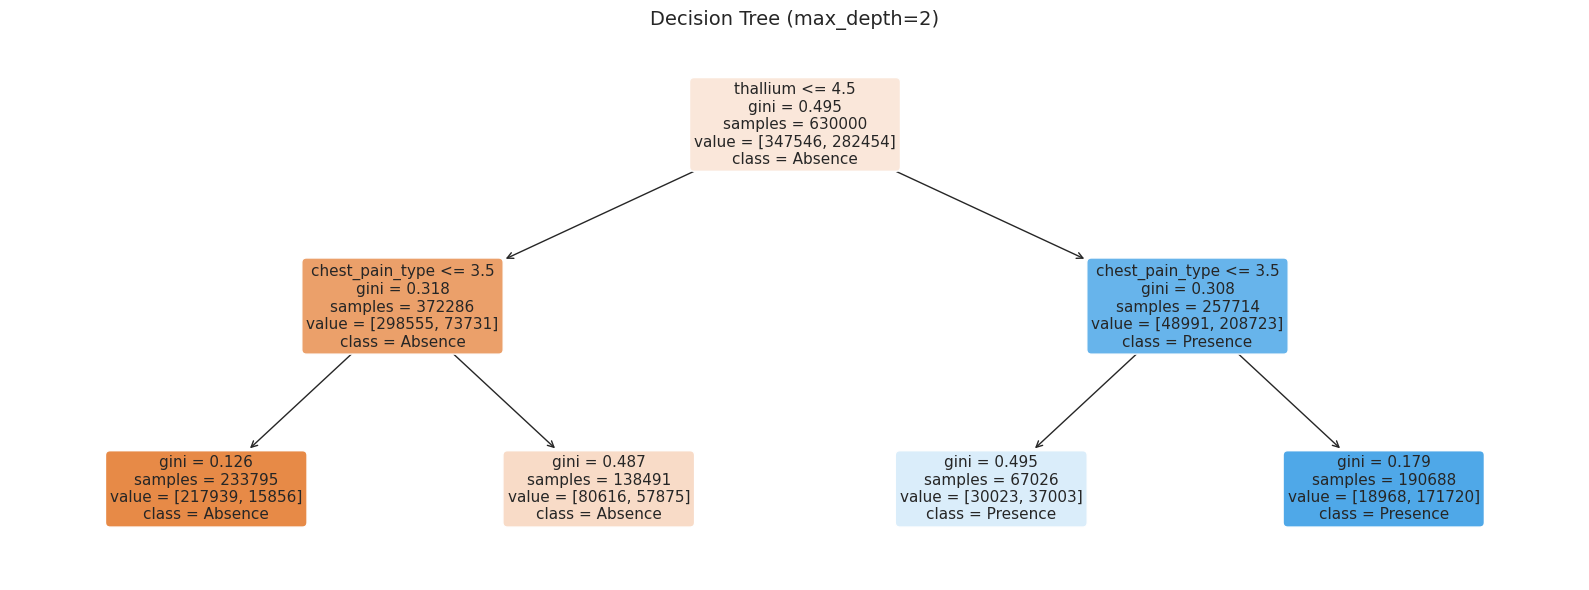

In [6]:
# Visualize the depth-2 tree
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(
    dt2,
    feature_names=FEATURES,
    class_names=["Absence", "Presence"],
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax,
)
plt.title("Decision Tree (max_depth=2)", fontsize=14)
plt.tight_layout()
plt.show()

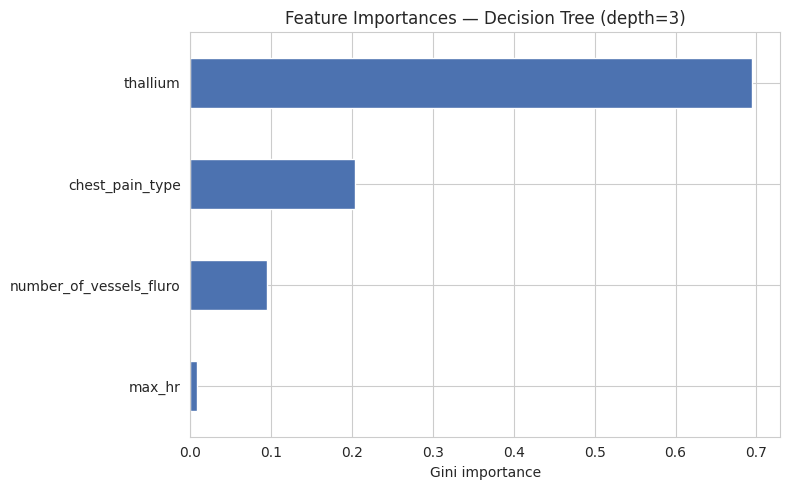

In [7]:
# Feature importances from depth-3 tree (more splits = richer importance signal)
dt3 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt3.fit(X, y)

importances = pd.Series(dt3.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances = importances[importances > 0]

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Feature Importances — Decision Tree (depth=3)")
ax.set_xlabel("Gini importance")
plt.tight_layout()
plt.show()

## Logistic Regression

In [8]:
# LR needs scaled inputs — pipeline handles that automatically
lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

lr_acc = cross_val_score(lr, X, y, cv=cv, scoring="accuracy").mean()
lr_auc = cross_val_score(lr, X, y, cv=cv, scoring="roc_auc").mean()
print(f"Logistic Regression  accuracy={lr_acc:.4f}  ROC-AUC={lr_auc:.4f}")

Logistic Regression  accuracy=0.8831  ROC-AUC=0.9505


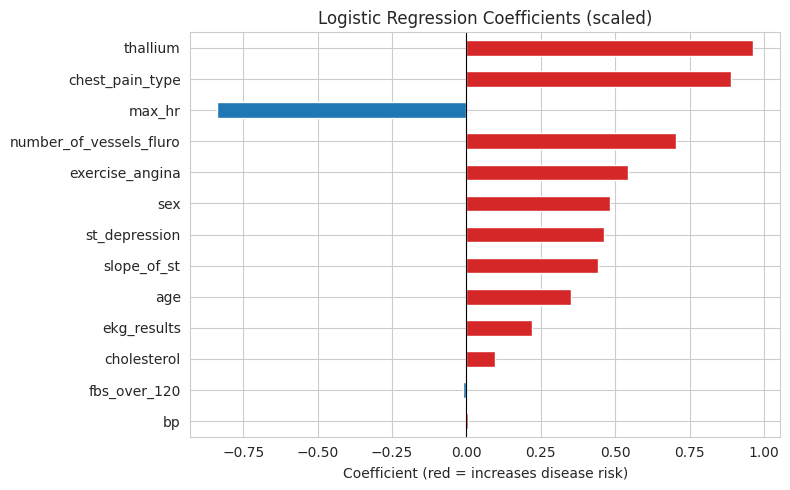

In [9]:
# Fit on full train to inspect coefficients
lr.fit(X, y)
coefs = pd.Series(lr.named_steps["logisticregression"].coef_[0], index=FEATURES)
coefs = coefs.sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d62728" if v > 0 else "#1f77b4" for v in coefs]
coefs.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression Coefficients (scaled)")
ax.set_xlabel("Coefficient (red = increases disease risk)")
plt.tight_layout()
plt.show()

## Model Comparison

                     accuracy  roc_auc  max_depth
model                                            
logistic_regression    0.8831   0.9505        NaN
dt_depth10             0.8812   0.9488       10.0
dt_depth9              0.8805   0.9485        9.0
dt_depth8              0.8783   0.9468        8.0
dt_depth7              0.8747   0.9440        7.0
dt_depth6              0.8725   0.9395        6.0
dt_depth5              0.8627   0.9327        5.0
dt_depth4              0.8540   0.9217        4.0
dt_depth3              0.8416   0.9058        3.0
dt_depth2              0.8052   0.8794        2.0
thallium_or_vessels    0.8089   0.8126        NaN
thallium_or_ex_ang     0.8094   0.8120        NaN
dt_depth1              0.8052   0.7990        1.0
thallium_only          0.8052   0.7990        NaN


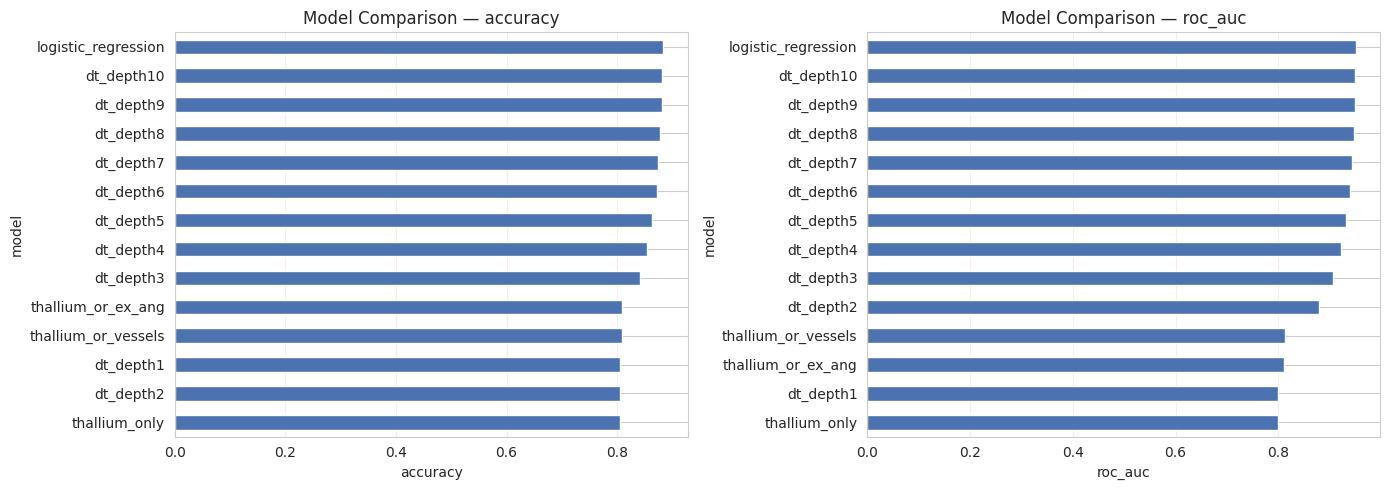

In [10]:
manual_scores = [
    {"model": "thallium_only",       "accuracy": 0.8052, "roc_auc": 0.7990},
    {"model": "thallium_or_vessels", "accuracy": 0.8089, "roc_auc": 0.8126},
    {"model": "thallium_or_ex_ang",  "accuracy": 0.8094, "roc_auc": 0.8120},
]

comparison = pd.DataFrame(manual_scores + results + [
    {"model": "logistic_regression", "accuracy": lr_acc, "roc_auc": lr_auc}
]).set_index("model").sort_values("roc_auc", ascending=False)

print(comparison.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["accuracy", "roc_auc"]):
    comparison[metric].sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_title(f"Model Comparison — {metric}")
    ax.set_xlabel(metric)
    ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Submission

Generate a submission file from the best-performing simple model (depth-3 tree) to establish a baseline before moving to more complex models.

In [11]:
# Fit best depth on full training data
best_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_dt.fit(X, y)

best_acc = results_df.loc[results_df["max_depth"] == best_depth, "accuracy"].values[0]
best_auc = results_df.loc[results_df["max_depth"] == best_depth, "roc_auc"].values[0]

preds = best_dt.predict(X_test)
submission = ss.copy()
submission["Heart Disease"] = preds

fname = f"submissions/dt_depth{best_depth}.csv"
desc  = f"dt_depth{best_depth} | cv_acc={best_acc:.4f} | cv_auc={best_auc:.4f}"
submission.to_csv(fname, index=False)

print(f"Saved: {fname}")
print(f"Description: {desc}")
print(f"Predictions: {submission['Heart Disease'].value_counts().to_dict()}")

Saved: submissions/dt_depth10.csv
Description: dt_depth10 | cv_acc=0.8812 | cv_auc=0.9488
Predictions: {0: 150530, 1: 119470}
